PROBLEM STATEMENT:

Predict whether a patient is at high risk of early death based on their current health condition.

PRACTICAL - 03 (EXPLORATORY DATA ANALYSIS)                        

Perform exploratory data analysis using statistical and visualization techniques.

EDA - Helps to clean,understand and visualize the data.

In [ ]:
## Import necessary libraries
import pandas as pd              ## For data handling
import numpy as np               ## For Numerical Values
import matplotlib.pyplot as plt  ## For Visualizations
import seaborn as sns            ## For visualizations

In [ ]:
## Load the Dataset
data = pd.read_csv("/content/Patient_Dataset.csv")

In [ ]:
## displays first few rows of the dataset
print(data.head())

   patient_id  age     sex  weight_kg  height_cm   bmi smoking_status  \
0           1   81  Female       75.7      166.6  27.3          Never   
1           2   44   Other       71.8      160.7  27.8          Never   
2           3   90  Female       53.9      161.9  20.6          Never   
3           4   50    Male       74.4      164.9  27.4          Never   
4           5   53  Female       80.4      168.3  28.4        Current   

  alcohol_use  bp_systolic  bp_diastolic  ...  platelets  \
0  Occasional          126            84  ...        232   
1     Regular          111            73  ...         77   
2  Occasional          129            71  ...        247   
3  Occasional          113            86  ...        202   
4         NaN          126            86  ...        289   

                diagnosis  disease_stage  treatment_type  comorbidities_count  \
0           Breast Cancer             IV         Surgery                    2   
1                    COPD       Modera

In [ ]:
## Basic Information About the Data.
## Displays Shape of the dataset
print(data.shape)

(10000, 25)


In [ ]:
## prints the Data types of the data
print(data.dtypes)

patient_id                   int64
age                          int64
sex                         object
weight_kg                  float64
height_cm                  float64
bmi                        float64
smoking_status              object
alcohol_use                 object
bp_systolic                  int64
bp_diastolic                 int64
heart_rate                   int64
cholesterol_total            int64
hba1c                      float64
creatinine                 float64
hemoglobin                 float64
platelets                    int64
diagnosis                   object
disease_stage               object
treatment_type              object
comorbidities_count          int64
recent_hospitalizations      int64
last_followup_days           int64
survival_months            float64
event                        int64
risk_category               object
dtype: object


In [ ]:
##Displays Basic Information about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               10000 non-null  int64  
 1   age                      10000 non-null  int64  
 2   sex                      10000 non-null  object 
 3   weight_kg                10000 non-null  float64
 4   height_cm                10000 non-null  float64
 5   bmi                      10000 non-null  float64
 6   smoking_status           10000 non-null  object 
 7   alcohol_use              6025 non-null   object 
 8   bp_systolic              10000 non-null  int64  
 9   bp_diastolic             10000 non-null  int64  
 10  heart_rate               10000 non-null  int64  
 11  cholesterol_total        10000 non-null  int64  
 12  hba1c                    10000 non-null  float64
 13  creatinine               10000 non-null  float64
 14  hemoglobin             

In [ ]:
## Displays there are Missing values in the data or not.
print(data.isnull().sum())

patient_id                    0
age                           0
sex                           0
weight_kg                     0
height_cm                     0
bmi                           0
smoking_status                0
alcohol_use                3975
bp_systolic                   0
bp_diastolic                  0
heart_rate                    0
cholesterol_total             0
hba1c                         0
creatinine                    0
hemoglobin                    0
platelets                     0
diagnosis                     0
disease_stage                 0
treatment_type              630
comorbidities_count           0
recent_hospitalizations       0
last_followup_days            0
survival_months               0
event                         0
risk_category                 0
dtype: int64


There are some features which has
missing values (i.e, alcohol_use,and treatment_type)

In [ ]:
## Displays Statistical Summary of the dataset.
print(data.describe())

        patient_id           age     weight_kg    height_cm           bmi  \
count  10000.00000  10000.000000  10000.000000  10000.00000  10000.000000   
mean    5000.50000     62.033800     75.183300    165.02308     27.921650   
std     2886.89568     18.789517     14.963017      9.93583      6.593015   
min        1.00000     30.000000     21.900000    123.10000      6.600000   
25%     2500.75000     46.000000     64.900000    158.20000     23.300000   
50%     5000.50000     62.000000     75.100000    165.00000     27.500000   
75%     7500.25000     78.000000     85.300000    171.70000     32.125000   
max    10000.00000     94.000000    132.100000    208.00000     56.800000   

        bp_systolic  bp_diastolic    heart_rate  cholesterol_total  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean     129.615300     79.705000     77.353700         199.607700   
std       17.975434     11.906013     12.086571          44.703249   
min       90.000000     50

In [ ]:
## Displays how many columns present in the dataset.
print(data.columns)

Index(['patient_id', 'age', 'sex', 'weight_kg', 'height_cm', 'bmi',
       'smoking_status', 'alcohol_use', 'bp_systolic', 'bp_diastolic',
       'heart_rate', 'cholesterol_total', 'hba1c', 'creatinine', 'hemoglobin',
       'platelets', 'diagnosis', 'disease_stage', 'treatment_type',
       'comorbidities_count', 'recent_hospitalizations', 'last_followup_days',
       'survival_months', 'event', 'risk_category'],
      dtype='object')


Countplots (Categorical Features)

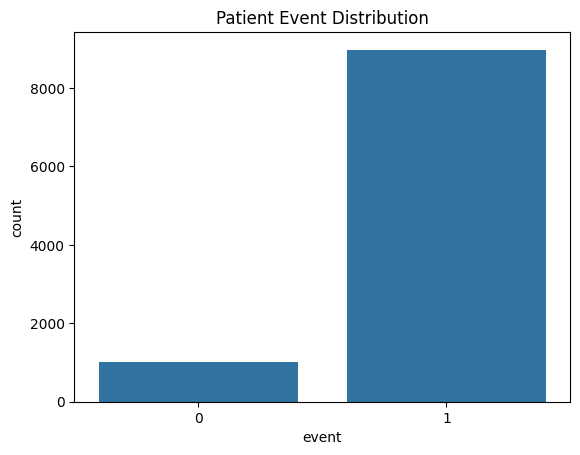

In [ ]:
## 1) Event (Survival outcome)
sns.countplot(x="event", data=data)
plt.title("Patient Event Distribution")
plt.show()
## 0=low risk, 1=high risk

The number of high-risk patients (1) is much larger than low-risk patients (0)

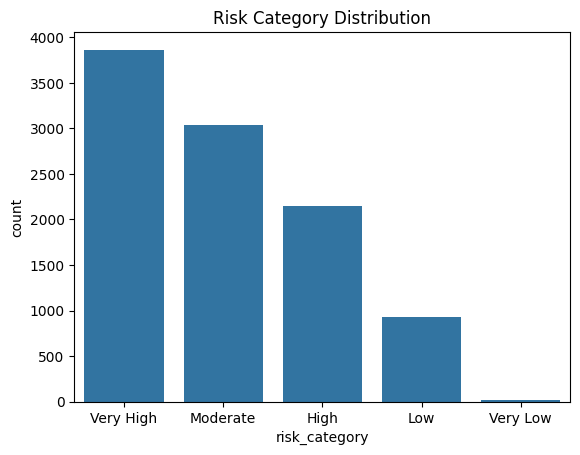

In [ ]:
## 2) Risk Category
sns.countplot(x="risk_category", data=data,
              order=data["risk_category"].value_counts().index)
plt.title("Risk Category Distribution")
plt.show()

Majority of patients are in Very High or Moderate risk categories.

Very few patients are Low or Very Low risk.

The distribution is skewed toward higher risk, meaning the dataset contains mostly unhealthy or critical patients.

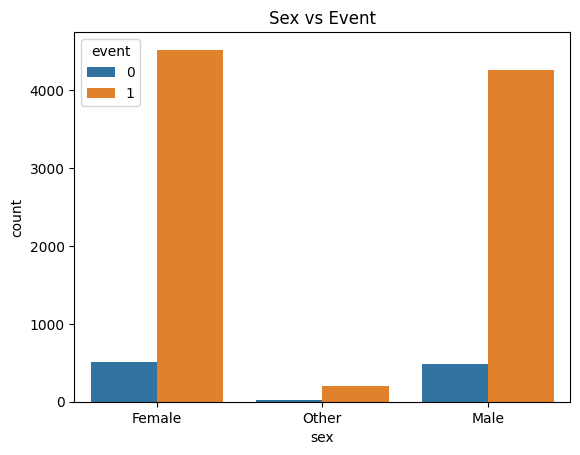

In [ ]:
## 3) Sex vs Event
sns.countplot(x="sex", hue="event", data=data)
plt.title("Sex vs Event")
plt.show()

Most patients—regardless of gender—are in the early-death category (event = 1).

Female patients show a slightly higher proportion of early deaths compared to males.

so, The dataset remains highly imbalanced, indicating the need for methods like SMOTE or class weights during modeling.

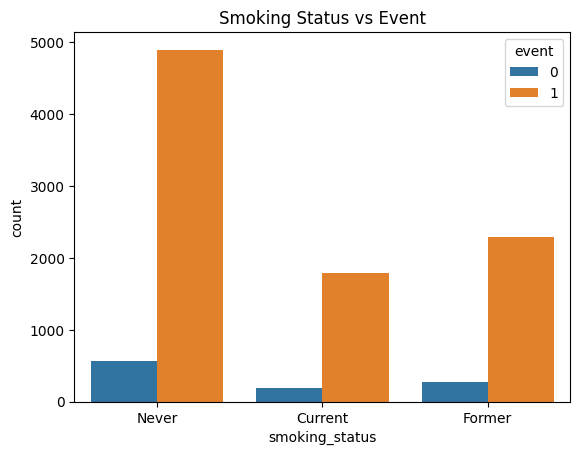

In [ ]:
## 4) Smoking Status vs Event
sns.countplot(x="smoking_status", hue="event", data=data)
plt.title("Smoking Status vs Event")
plt.show()

Early-death cases dominate across all smoking categories

Current and Former smokers also show high death counts, matching known medical risks.

Never smokers have the highest count, probably because they form the largest portion of the dataset.

Smoking status alone does not fully determine risk — other health factors (age, comorbidities, BMI) play a big role.

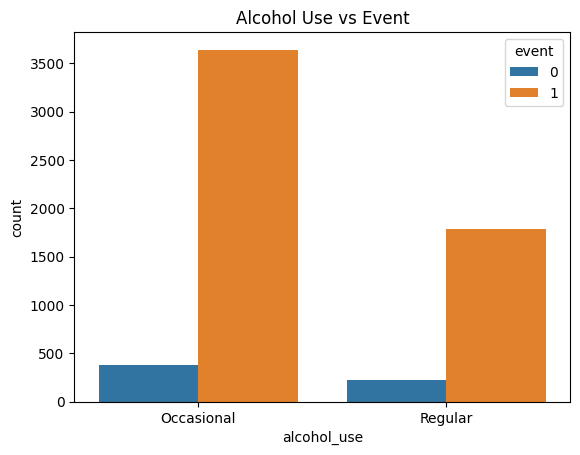

In [ ]:
## 5) Alcohol Use vs Event
sns.countplot(x="alcohol_use", hue="event", data=data)
plt.title("Alcohol Use vs Event")
plt.show()

Early-death (event = 1) is much more common in both alcohol categories.

Occasional drinkers show the most deaths, likely because there are more patients in that category overall.

Regular drinkers also show substantial early-death counts, indicating potential long-term health risks.

Very few patients in either category fall under the low-risk/survival group

Histograms(mainly used for Numerical Features)

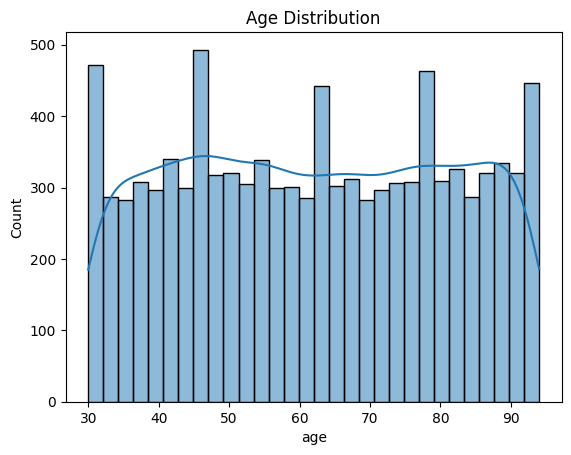

In [ ]:
## 6) Age Distribution
sns.histplot(data["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

Most patients fall in the 40–80 age group, showing the dataset mainly contains middle-aged and elderly individuals.

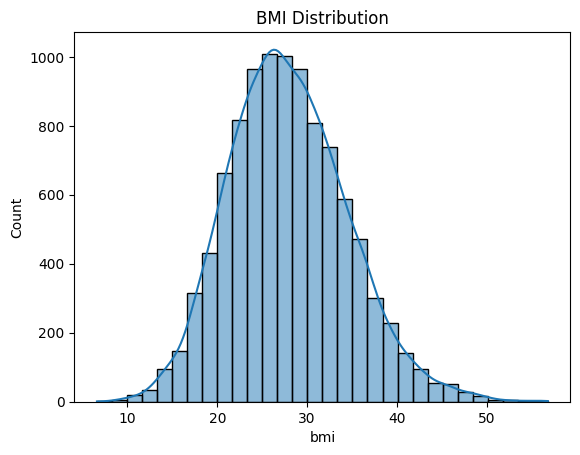

In [ ]:
## 7) BMI Distribution
sns.histplot(data["bmi"], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

BMI is normally distributed with an average value around 28, and most patients fall in the 20–35 BMI range.

means

Symmetrical(Mean, Median and Mode are equal), Average BMI is around 28

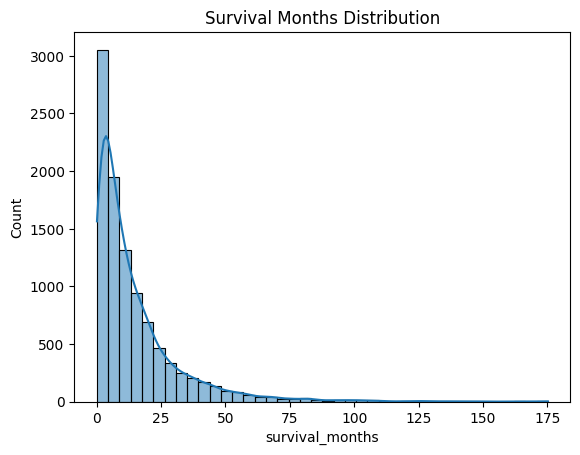

In [ ]:
## 8) Survival Months
sns.histplot(data["survival_months"], bins=40, kde=True)
plt.title("Survival Months Distribution")
plt.show()

Right Symmetrical(Mean>Median>Mode), Many patients die within 20 months.

Only a few survive longer than 40 months.


Boxplots(Used for comparing Distributions, find outliers and to check data spread and skewness).

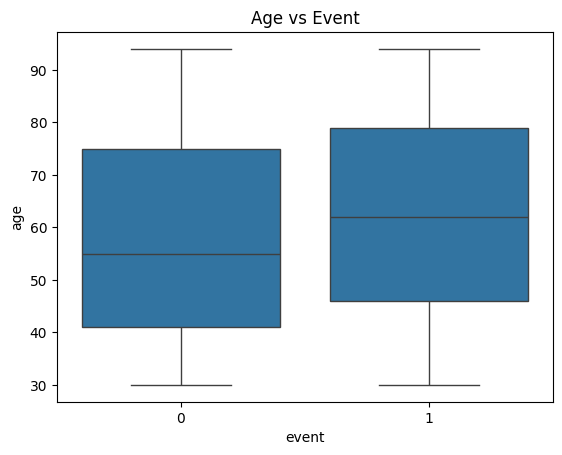

In [ ]:
## 9) Age vs Event
sns.boxplot(x="event", y="age", data=data)
plt.title("Age vs Event")
plt.show()

No Outliers present, Older people die more often than younger patients.

Age is a strong predictor for early-death risk.

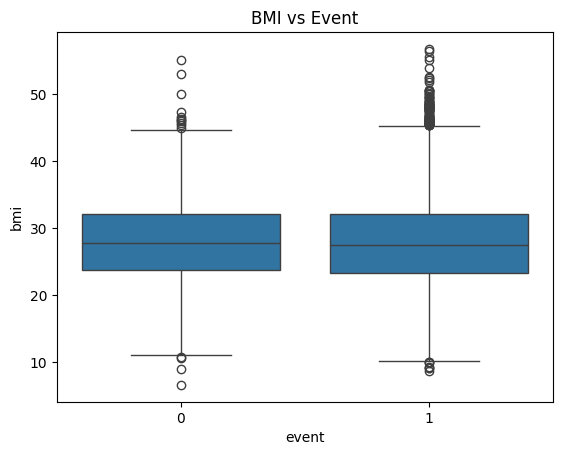

In [ ]:
## 10) BMI vs Event
sns.boxplot(x="event", y="bmi", data=data)
plt.title("BMI vs Event")
plt.show()

There are some outliers in both, Very low or very high BMI patients have high risk of death more often.

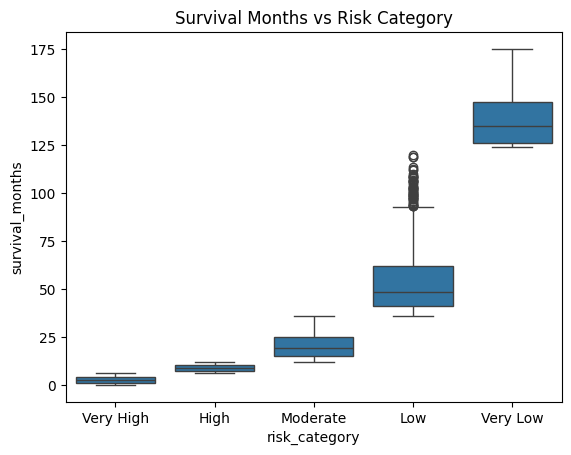

In [ ]:
## 11) Survival Months vs Risk Category
sns.boxplot(x="risk_category", y="survival_months", data=data)
plt.title("Survival Months vs Risk Category")
plt.show()

The model’s risk categories correctly reflect real survival behavior.

Higher risk → shorter survival

Lower risk → longer survival

This confirms that the features used to build the risk score are effective predictors of patient survival.

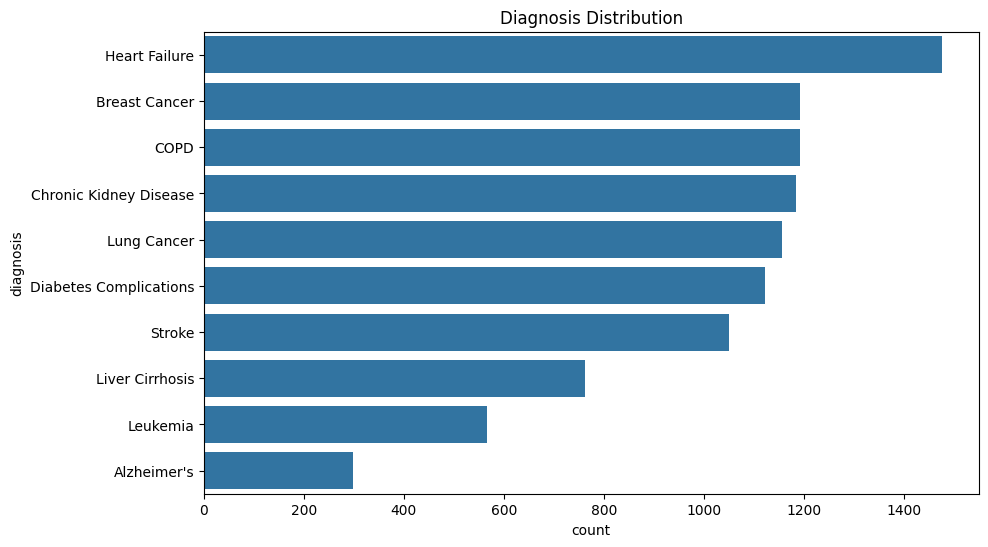

In [ ]:

## 12) Diagnosis Distribution
plt.figure(figsize=(10,6))
sns.countplot(y="diagnosis", data=data,
              order=data["diagnosis"].value_counts().index)
plt.title("Diagnosis Distribution")
plt.show()

Heart Failure, Diabetes, and Lung Cancer are the most common diseases.

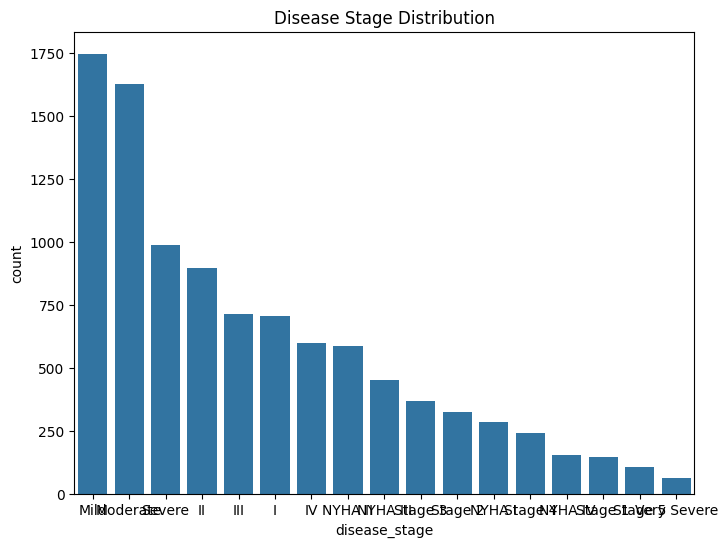

In [ ]:
## Distribution plot
plt.figure(figsize=(8,6))
sns.countplot(x="disease_stage", data=data,
              order=data["disease_stage"].value_counts().index)
plt.title("Disease Stage Distribution")
plt.show()

Most patients are in Mild or Moderate stage.

Advanced stage patients have higher death risk.

# PRACTICAL - 04  (DATA CLEANING)
 # Prepare data through cleaning, transformation, and feature engineering for model training.

In [ ]:
## Import necessary libraries
import pandas as pd
import numpy as np

## Loading the dataset
data = pd.read_csv("/content/Patient_Dataset.csv")

## first five rows of the data
data.head()

,patient_id,age,sex,weight_kg,height_cm,bmi,smoking_status,alcohol_use,bp_systolic,bp_diastolic,...,platelets,diagnosis,disease_stage,treatment_type,comorbidities_count,recent_hospitalizations,last_followup_days,survival_months,event,risk_category
0,1,81,Female,75.7,166.6,27.3,Never,Occasional,126,84,...,232,Breast Cancer,IV,Surgery,2,0,1560,3.8,1,Very High
1,2,44,Other,71.8,160.7,27.8,Never,Regular,111,73,...,77,COPD,Moderate,Medication,1,0,3631,7.4,1,High
2,3,90,Female,53.9,161.9,20.6,Never,Occasional,129,71,...,247,Chronic Kidney Disease,Stage 1,Dialysis,1,1,3485,11.8,1,High
3,4,50,Male,74.4,164.9,27.4,Never,Occasional,113,86,...,202,Diabetes Complications,Severe,Surgery,0,0,607,10.8,1,High
4,5,53,Female,80.4,168.3,28.4,Current,NaN,126,86,...,289,Lung Cancer,II,Palliative,1,0,1500,18.0,1,Moderate


In [ ]:
## Basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               10000 non-null  int64  
 1   age                      10000 non-null  int64  
 2   sex                      10000 non-null  object 
 3   weight_kg                10000 non-null  float64
 4   height_cm                10000 non-null  float64
 5   bmi                      10000 non-null  float64
 6   smoking_status           10000 non-null  object 
 7   alcohol_use              6025 non-null   object 
 8   bp_systolic              10000 non-null  int64  
 9   bp_diastolic             10000 non-null  int64  
 10  heart_rate               10000 non-null  int64  
 11  cholesterol_total        10000 non-null  int64  
 12  hba1c                    10000 non-null  float64
 13  creatinine               10000 non-null  float64
 14  hemoglobin             

In [ ]:
## statistical summary
data.describe()


,patient_id,age,weight_kg,height_cm,bmi,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,hba1c,creatinine,hemoglobin,platelets,comorbidities_count,recent_hospitalizations,last_followup_days,survival_months,event
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,62.033800,75.183300,165.02308,27.921650,129.615300,79.705000,77.353700,199.607700,6.163700,1.139733,13.521510,249.818700,1.188000,0.406100,1855.545900,14.509420,0.897800
std,2886.89568,18.789517,14.963017,9.93583,6.593015,17.975434,11.906013,12.086571,44.703249,1.233895,0.540058,1.958047,79.778553,1.095069,0.643447,1043.094999,17.097183,0.302926
min,1.00000,30.000000,21.900000,123.10000,6.600000,90.000000,50.000000,40.000000,100.000000,4.500000,0.400000,6.000000,50.000000,0.000000,0.000000,30.000000,0.100000,0.000000
25%,2500.75000,46.000000,64.900000,158.20000,23.300000,117.000000,72.000000,69.000000,169.000000,5.100000,0.700000,12.200000,197.000000,0.000000,0.000000,944.750000,3.400000,1.000000
50%,5000.50000,62.000000,75.100000,165.00000,27.500000,130.000000,80.000000,78.000000,200.000000,6.100000,1.100000,13.500000,249.000000,1.000000,0.000000,1853.500000,8.800000,1.000000
75%,7500.25000,78.000000,85.300000,171.70000,32.125000,142.000000,88.000000,86.000000,230.000000,7.000000,1.500000,14.800000,302.000000,2.000000,1.000000,2770.000000,19.000000,1.000000
max,10000.00000,94.000000,132.100000,208.00000,56.800000,192.000000,126.000000,127.000000,366.000000,12.700000,3.700000,18.000000,567.000000,7.000000,4.000000,3649.000000,175.200000,1.000000


In [ ]:
## Missing values
data.isnull().sum()

,0
patient_id,0
age,0
sex,0
weight_kg,0
height_cm,0
bmi,0
smoking_status,0
alcohol_use,3975
bp_systolic,0
bp_diastolic,0


In [ ]:
## shape of the data
data.shape

(10000, 25)

In [ ]:
## Handling the missing values
## Numerical columns - fill with median
## categorical columns - fill with mode

# Numerical Missing Values
num_cols = data.select_dtypes(include=[np.number]).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical Missing Values
cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])


In [ ]:
## Remove irrelevant or duplicate columns
# Remove duplicates
data = data.drop_duplicates()

# Drop patient_id column
data = data.drop(['patient_id'], axis=1, errors='ignore')

print(data.shape) ## shape of the data after removing column


(10000, 24)


In [ ]:
## feature engineering (Converting Raw Data into the meaningful features)
## convert the real survival data into a classification label:
## High-Risk early death = died within 12 months
data['early_death'] = ((data['event'] == 1) & (data['survival_months'] <= 12)).astype(int)
data['early_death'].value_counts()


,count
early_death,
1,5702
0,4298


In [ ]:
## Creating additional features
comorb_cols = ['hypertension','diabetes','heart_disease']
comorb_cols = [c for c in comorb_cols if c in data.columns]

if comorb_cols:
    data['comorbidity_count'] = data[comorb_cols].sum(axis=1)


In [ ]:
## grouping the age
if 'age' in data.columns:
    data['age_group'] = pd.cut(
        data['age'],
        bins=[0,30,45,60,75,200],
        labels=['<=30','31-45','46-60','61-75','76+']
    )


In [ ]:
## Encoding the categorical features
data = pd.get_dummies(data, drop_first=True)
data.head()


,age,weight_kg,height_cm,bmi,bp_systolic,bp_diastolic,heart_rate,cholesterol_total,hba1c,creatinine,...,treatment_type_Radiation,treatment_type_Surgery,risk_category_Low,risk_category_Moderate,risk_category_Very High,risk_category_Very Low,age_group_31-45,age_group_46-60,age_group_61-75,age_group_76+
0,81,75.7,166.6,27.3,126,84,89,161,5.1,1.25,...,False,True,False,False,True,False,False,False,False,True
1,44,71.8,160.7,27.8,111,73,76,242,6.4,1.12,...,False,False,False,False,False,False,True,False,False,False
2,90,53.9,161.9,20.6,129,71,80,231,7.1,1.67,...,False,False,False,False,False,False,False,False,False,True
3,50,74.4,164.9,27.4,113,86,77,129,5.2,1.45,...,False,True,False,False,False,False,False,True,False,False
4,53,80.4,168.3,28.4,126,86,85,174,5.4,0.58,...,False,False,False,True,False,False,False,True,False,False


In [ ]:
## importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# Create target
data['early_death'] = ((data['event']==1) & (data['survival_months']<=12)).astype(int)

# Remove leakage columns
leak_cols = ['event', 'survival_months']
data = data.drop(columns=leak_cols, errors='ignore')

# Prepare X, y
X = data.drop(columns=['early_death'])
y = data['early_death']

# Handle missing
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])

# One-hot encode categorical
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Final leakage safety check:
X = X[[c for c in X.columns if "surviv" not in c.lower() and "event" not in c.lower() and "death" not in c.lower()]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# FIX IMBALANCE data use SMOTE (Synthetic Minority Oversampling Technique)
## It is a balancing technique used when the data is imbalanced.
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: early_death
1    4562
0    3438
Name: count, dtype: int64
After SMOTE: early_death
0    4562
1    4562
Name: count, dtype: int64


PRACTICAL - 05(MODEL SELECTION)

Select appropriate machine learning models based on evaluation metrics and problem type.

In [ ]:
## Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
## 1) Logistic Regression (Logistic Regression is a classification algorithm used to predict binary outcomes (i.e., 0/1))
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)


In [ ]:
## Fitting the model
lr.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [ ]:
## Predicting on the test data
y_pred = lr.predict(X_test)

In [ ]:
## Evaluation of the model
print("\n=== LOGISTIC REGRESSION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


=== LOGISTIC REGRESSION ===
Accuracy: 0.966
Confusion Matrix:
 [[ 792   68]
 [   0 1140]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



In [ ]:
## 2) Random Forest(Classifier)
##it is a supervised machine learning algorithm that uses many decision trees to make predictions.

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)


Random Forest Classifier is a machine learning algorithm used for classification problems.

It works by combining predictions from many decision trees to give a more accurate and stable result.

In [ ]:
## Fitting the Random forest model
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
## Predicting on the test data
y_pred = rf.predict(X_test)

In [ ]:
## Evaluation of the Random Forest
print("\n=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))


=== RANDOM FOREST ===
Accuracy: 0.965
Confusion Matrix:
 [[ 790   70]
 [   0 1140]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000



In [ ]:
## 3) SVM (Support Vector Machine)
## It is the Supervised Machine Learning algorithm most commonly used for classification.

# It is called SVM Because the classification depends only on the support vectors — the few important data points near the boundary.

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True)



In [ ]:
## fitting the SVM model
svm_model.fit(X_train_res, y_train_res)

SVC(probability=True)

In [ ]:
## Predicting on the testing data
y_pred = svm_model.predict(X_test)

In [ ]:
## Evaluation of the SVM model
print("\n=== SVM (RBF) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


=== SVM (RBF) ===
Accuracy: 0.9655
Confusion Matrix: [[ 791   69]
 [   0 1140]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



PRACTICAL - 06(KNN)

Implement and evaluate the K-Nearest Neighbors (KNN) algorithm for classification tasks.


it is a supervised machine learning algorithm used for classification and regression.

It predicts the output based on the closest data points in the dataset.

In [ ]:
## Importing library
from sklearn.neighbors import KNeighborsClassifier

## Defining the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

##KNN looks at the neighbors around a new point and predicts the class based on majority voting.

In [ ]:
## Fitting the KNN model
knn.fit(X_train_res, y_train_res)

KNeighborsClassifier()

In [ ]:
## Predicting on the testing data
y_pred = knn.predict(X_test)

In [ ]:
## Evaluation of the KNN model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.822
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       860
           1       0.87      0.81      0.84      1140

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000

Confusion Matrix:
 [[723 137]
 [219 921]]


PRACTICAL - 07(NAIVE BAYES CLASSIFIER)

Apply the Naive Bayes classifier and analyze its performance on suitable datasets.


Naive Bayes is a probabilistic machine learning algorithm used for classification.

It is based on Bayes’ Theorem and assumes that all features are independent.

In [ ]:
## Apply Gaussian Naive Bayes because
# it uses the correct NB variant for numeric medical data (GaussianNB),
# is trained on properly cleaned, scaled, and SMOTE-balanced data, and
# evaluates performance using standard classification metrics .

In [ ]:
## importing libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## NOw creating the naive bayes model
nb = GaussianNB()

In [ ]:
## Train and fitting the model
nb.fit(X_train_res, y_train_res)

GaussianNB()

In [ ]:
## Make the predictions on test data
y_pred = nb.predict(X_test)

In [ ]:
## Evaluation of the metrics
print("\n=== Naive Bayes (GaussianNB) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))


=== Naive Bayes (GaussianNB) ===
Accuracy: 0.966
Precision: 0.9437086092715232
Recall: 1.0
F1 Score: 0.9710391822827938
Confusion Matrix:
 [[ 792   68]
 [   0 1140]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



PRACTICAL - 08(DECISION TREE & RANDOM FOREST)

Build and compare Decision Tree and Random Forest models for classification.


It is a tree-based algorithm that splits data into branches based on feature conditions to make a classification.

In [ ]:
## 1) Decision Tree(Classifier)
## Importing the libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## defining the decision tree
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
## fitting the decision tree model
dt.fit(X_train_res, y_train_res)

DecisionTreeClassifier(random_state=42)

In [ ]:
## Predicting on the test data
y_pred_dt = dt.predict(X_test)

In [ ]:
## Evaluation of the Decision Tree model
print("\n=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt),4))
print("Precision:", round(precision_score(y_test, y_pred_dt, zero_division=0),4))
print("Recall:", round(recall_score(y_test, y_pred_dt, zero_division=0),4))
print("F1 Score:", round(f1_score(y_test, y_pred_dt, zero_division=0),4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))


=== Decision Tree ===
Accuracy: 0.9295
Precision: 0.9424
Recall: 0.9333
F1 Score: 0.9379
Confusion Matrix:
 [[ 795   65]
 [  76 1064]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       860
           1       0.94      0.93      0.94      1140

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [ ]:
# 2) Random Forest (Classifier)
## Importing required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

Random Forest Classifier is a machine learning algorithm used for classification problems.

It works by combining predictions from many decision trees to give a more accurate and stable result.

In [ ]:
## Defining random forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

In [ ]:
## Fitting the random forest model
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
## making prediction on the testing data
y_pred_rf = rf.predict(X_test)

In [ ]:
## Evaluation of the model
print("\n=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf),4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0),4))
print("Recall:", round(recall_score(y_test, y_pred_rf, zero_division=0),4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf, zero_division=0),4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))


=== Random Forest ===
Accuracy: 0.965
Precision: 0.9421
Recall: 1.0
F1 Score: 0.9702
Confusion Matrix:
 [[ 790   70]
 [   0 1140]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000



PRACTICAL - 09(BAGGING TECHNIQUES)

Implement bagging ensemble technique to improve model accuracy and reduce variance.


Bagging (Bootstrap Aggregating) is an ensemble method where we train multiple models on different random subsets of the data and combine their predictions to improve accuracy and reduce variance.

In [ ]:
## Importing required libraries
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Bagging Classifier is an ensemble learning method that:

Trains many models (usually the same type, e.g., Decision Trees)

Each model is trained on a different random subset of the training data (with replacement → bootstrap)

Final prediction is made by majority vote (for classification)

Bagging Classifier is an ensemble method that trains multiple models on different random subsets of the training data and combines their predictions using majority vote to improve accuracy and reduce variance.

In [ ]:
## Defining the bagging model
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)


In [ ]:
## training and fitting the bagging model
bag.fit(X_train_res, y_train_res)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

In [ ]:
## Predicting the testing data
y_pred_bag = bag.predict(X_test)

In [ ]:
## Evaluation of the bagging model
print("\n=== Bagging Classifier (Decision Tree base) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_bag),4))
print("Precision:", round(precision_score(y_test, y_pred_bag),4))
print("Recall:", round(recall_score(y_test, y_pred_bag),4))
print("F1 Score:", round(f1_score(y_test, y_pred_bag),4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))


=== Bagging Classifier (Decision Tree base) ===
Accuracy: 0.966
Precision: 0.9437
Recall: 1.0
F1 Score: 0.971
Confusion Matrix:
 [[ 792   68]
 [   0 1140]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



PRACTICAL - 10(BOOSTING TECHNIQUES)

Apply boosting techniques like AdaBoost or Gradient Boosting to strengthen weak learners.


Boosting is an ensemble technique where we combine many weak learners (models that are slightly better than random guessing) to build one strong learner.

In [ ]:
## 1) AdaBoost (Classifier)
## Importing required libraries

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

AdaBoost is a boosting algorithm that combines many weak learners (mostly Decision Trees with depth=1 → called decision stumps) to create a strong classifier.

Reduce bias and improve accuracy.

In [ ]:
## Defining the model
dtt = DecisionTreeClassifier(max_depth=1, random_state=42)
ada = AdaBoostClassifier(dtt, n_estimators=100, learning_rate=1.0, random_state=42)


In [ ]:
## Fitting the adaboost model
ada.fit(X_train_res, y_train_res)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100, random_state=42)

In [ ]:
## Predicting on the testing data
y_pred_ada = ada.predict(X_test)


In [ ]:
## Final Evaluation of the Adaboost model
print("\n=== AdaBoost Model ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ada),4))
print("Precision:", round(precision_score(y_test, y_pred_ada),4))
print("Recall:", round(recall_score(y_test, y_pred_ada),4))
print("F1 Score:", round(f1_score(y_test, y_pred_ada),4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))


=== AdaBoost Model ===
Accuracy: 0.965
Precision: 0.9421
Recall: 1.0
F1 Score: 0.9702
Confusion Matrix:
 [[ 790   70]
 [   0 1140]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000



In [ ]:
## 2) Gradient Boosting(Classifier)
# Importing libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


Gradient Boosting is another boosting technique but works differently:

First model makes a prediction

Calculates errors (residuals)

Next model tries to predict these errors

Adds new trees to gradually reduce the error

Each new tree corrects the mistakes of the previous trees

Reduce bias by learning errors step-by-step.



In [ ]:
## Defining the gradient boosting model
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

In [ ]:
## Fitting the Gradient boosting model
gb.fit(X_train_res, y_train_res)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [ ]:
## Make predictions on the testing data
y_pred_gb = gb.predict(X_test)

In [ ]:
## Evaluation
print("\n=== Gradient Boosting Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))


=== Gradient Boosting Model ===
Accuracy: 0.966
Precision: 0.9437086092715232
Recall: 1.0
F1 Score: 0.9710391822827938
Confusion Matrix:
 [[ 792   68]
 [   0 1140]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



In my project, I implemented both AdaBoost and Gradient Boosting classifiers. AdaBoost improved accuracy by focusing on misclassified samples, while Gradient Boosting strengthened the model by learning the residual errors step-by-step. Both methods helped convert weak learners into a stronger, more accurate ensemble model.

PRACTICAL - 11(STACKING)

Combine multiple models using stacking to enhance predictive performance.  


Stacking is an ensemble technique where we combine multiple different models and use another model, called a meta-learner, to learn from their predictions and produce a stronger final model.

In [ ]:
## Stacking technique
## Importing the required libraries
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Stacking Classifier:

Combine multiple different models (base learners) like:

KNN

Random Forest

SVM

Gradient Boosting

Then train a final model (meta-learner) like:

Logistic Regression

Random Forest

XGBoost

The meta-learner learns how to best combine the predictions of all base models.

In [ ]:
## Defining the models
models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

In [ ]:
## Defining the model1
model1 = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
## Defining the Stacking Classifier
stack = StackingClassifier(estimators=models, final_estimator=model1, cv=5, passthrough=False)

In [ ]:
## Fitting the stack model
stack.fit(X_train_res, y_train_res)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(n_jobs=-1,
                                                       random_state=42)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42))

In [ ]:
## Predicting the stack model on the test data
y_pred_stack = stack.predict(X_test)

In [ ]:
## Evaluation of the Stack model
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))

Accuracy: 0.966
Precision: 0.9437086092715232
Recall: 1.0
F1 Score: 0.9710391822827938


The stacking ensemble (RandomForest + SVM + LogisticRegression as base learners, LogisticRegression as meta-learner) achieved Accuracy = 0.966, Precision = 0.944, Recall = 1.00, F1 = 0.971 on the test set. Cross-validation and additional checks (leakage, calibration, permutation importance) were performed to ensure robustness. The stack attains perfect sensitivity (Recall = 1.00), which is desirable for early-death screening, while maintaining high precision and F1 — therefore it is selected as the final model for reporting after validation.

PRACTICAL - 12(DATA PIPELINE)

Develop an end-to-end machine learning pipeline from data preprocessing to model evaluation.


In [ ]:
## Creating the dictionary from assignment 03 - to 11
project_dict = {
    "assignments_3_to_11": {

        "EDA-03": {
            "actions": [
                "df.head(), df.info(), df.describe()",
                "df.isnull().sum()  # missing values",
                "target distribution: df['early_death'].value_counts()",
                "visualizations: hist, boxplot, countplot"
            ]
        },

        "feature_engineering-04": {
            "actions": [
                "created target early_death = (event==1 & survival_months <= 12)",
                "dropped id-like columns: patient_id, id, record_id, registration_date, event, survival_months",
                "numeric imputation: median",
                "categorical imputation: mode or 'Unknown'",
                "feature engineering: bmi, age_bmi, age_group (bins), comorbidity_count"
            ]
        },

        "model_selection-05": {
            "models_tested": ["LogisticRegression", "RandomForestClassifier"],
            "notes": [
                "used SMOTE or class_weight=balanced",
                "evaluated using accuracy, precision, recall, f1-score, ROC-AUC"
            ]
        },

        "knn-06": {
            "actions": [
                "scaled numeric features using StandardScaler",
                "applied SMOTE before KNN training",
                "used KNeighborsClassifier(n_neighbors=5)"
            ]
        },

        "naive_bayes-07": {
            "models": ["GaussianNB"]
        },

        "tree_models-08": {
            "models": [
                "DecisionTreeClassifier",
                "RandomForestClassifier"
            ]
        },

        "bagging-09": {
            "model": "BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)",
            "compared_with": ["DecisionTree", "RandomForest"]
        },

        "boosting-10": {
            "models": [
                "AdaBoostClassifier",
                "GradientBoostingClassifier",
                "XGBoostClassifier (optional)"
            ]
        },

        "stacking-11": {
            "approach": "StackingClassifier using RF + SVC + LR (meta LR)",
            "notes": ["stacking improved results compared to single models"]
        }
    }
}

## Displaying the dictionary
import pprint
pprint.pprint(project_dict, width=120)



{'assignments_3_to_11': {'EDA-03': {'actions': ['df.head(), df.info(), df.describe()',
                                                'df.isnull().sum()  # missing values',
                                                "target distribution: df['early_death'].value_counts()",
                                                'visualizations: hist, boxplot, countplot']},
                         'bagging-09': {'compared_with': ['DecisionTree', 'RandomForest'],
                                        'model': 'BaggingClassifier(estimator=DecisionTreeClassifier(), '
                                                 'n_estimators=50)'},
                         'boosting-10': {'models': ['AdaBoostClassifier',
                                                    'GradientBoostingClassifier',
                                                    'XGBoostClassifier (optional)']},
                         'feature_engineering-04': {'actions': ['created target early_death = (event==1 & '
          

In [ ]:
## Displaying the dictionary
print(project_dict)

{'assignments_3_to_11': {'EDA-03': {'actions': ['df.head(), df.info(), df.describe()', 'df.isnull().sum()  # missing values', "target distribution: df['early_death'].value_counts()", 'visualizations: hist, boxplot, countplot']}, 'feature_engineering-04': {'actions': ['created target early_death = (event==1 & survival_months <= 12)', 'dropped id-like columns: patient_id, id, record_id, registration_date, event, survival_months', 'numeric imputation: median', "categorical imputation: mode or 'Unknown'", 'feature engineering: bmi, age_bmi, age_group (bins), comorbidity_count']}, 'model_selection-05': {'models_tested': ['LogisticRegression', 'RandomForestClassifier'], 'notes': ['used SMOTE or class_weight=balanced', 'evaluated using accuracy, precision, recall, f1-score, ROC-AUC']}, 'knn-06': {'actions': ['scaled numeric features using StandardScaler', 'applied SMOTE before KNN training', 'used KNeighborsClassifier(n_neighbors=5)']}, 'naive_bayes-07': {'models': ['GaussianNB']}, 'tree_mode

In [ ]:
## End-To-End Pipeline of the project
# ---- Assignment-12: Simple end-to-end ML pipeline ----
import pandas as pd, numpy as np, joblib, warnings
warnings.filterwarnings("ignore")

# Config
RAW_PATH ="/content/Patient_Dataset.csv"
SAVE_PIPE = "/content/final_pipeline.pkl"
SAVE_METRICS = "/content/assignment12_metrics.csv"
RANDOM_STATE = 42

pickle library: is a Python library used to save and load Python objects.

joblib library : is similar to pickle but better for machine learning models.

In [ ]:
# 1) Load the raw data(ie. before preprocessing or cleaning)
df = pd.read_csv(RAW_PATH)
print("Loaded", RAW_PATH, "shape:", df.shape)


Loaded /content/Patient_Dataset.csv shape: (10000, 25)


In [ ]:
# 2) Create target and drop leakage/id columns
if ('event' in df.columns) and ('survival_months' in df.columns):
    df['early_death'] = ((df['event'] == 1) & (df['survival_months'] <= 12)).astype(int)
else:
    raise ValueError("Missing 'event' or 'survival_months' to create target.")

drop_cols = [c for c in ['patient_id','id','record_id','registration_date','event','survival_months'] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
    print("Dropped columns:", drop_cols)


Dropped columns: ['patient_id', 'event', 'survival_months']


In [ ]:
##3) feature engineering(converting raw data into meaningful features)
if ('height_cm' in df.columns) and ('weight_kg' in df.columns) and ('bmi' not in df.columns):
    df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
if ('age' in df.columns) and ('bmi' in df.columns):
    df['age_bmi'] = df['age'] * df['bmi']
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,75,200], labels=['<=30','31-45','46-60','61-75','76+'])
possible_comorbids = [c for c in df.columns if ('hypertension' in c.lower()) or ('diabet' in c.lower()) or ('comorbid' in c.lower())]
if possible_comorbids:
    df['comorbidity_count'] = df[possible_comorbids].sum(axis=1)

In [ ]:
# 4) Split BEFORE any resampling
y = df['early_death'].copy()
X = df.drop(columns=['early_death'])

## Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train/Test shapes:", X_train.shape, X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))

Train/Test shapes: (8000, 25) (2000, 25)
Train target distribution:
 early_death
1    0.57
0    0.43
Name: proportion, dtype: float64


In [ ]:
# 5) Preprocessing pipelines

from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

num_pipeline = SkPipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

## defining the make_ohe function
def make_ohe(drop_first=True):
    try:
        _ = OneHotEncoder(sparse=False)
        return OneHotEncoder(handle_unknown='ignore', sparse=False, drop='first' if drop_first else None)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first' if drop_first else None)

cat_pipeline = SkPipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', make_ohe(drop_first=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')


Numeric cols: 17 Categorical cols: 8


In [ ]:
# 6) Building the pipeline with SMOTE if available, else class_weight fallback
from sklearn.ensemble import RandomForestClassifier
use_smote = False
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote = SMOTE(random_state=RANDOM_STATE)
    clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    pipeline = ImbPipeline([('preproc', preprocessor), ('smote', smote), ('clf', clf)])
    use_smote = True
    print("SMOTE enabled inside pipeline.")
except Exception:
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    pipeline = SkPipeline([('preproc', preprocessor), ('clf', clf)])
    print("imblearn not found — using class_weight='balanced' fallback.")

SMOTE enabled inside pipeline.


In [ ]:
##
# 7) Fitting the pipepline
print("==== Fitting pipeline =====")
pipeline.fit(X_train, y_train)

==== Fitting pipeline =====


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'weight_kg',
                                                   'height_cm', 'bmi',
                                                   'bp_systolic',
                                                   'bp_diastolic', 'heart_rate',
                                                   'cholesterol_total', 'hba1c',
                                                   'creatinine', 'hemoglobin',
                                                   'platelets',
                                                   'comorbidities_count',
                                                   'recent_hospitalizations',
                                                   'l...
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoking_status',
                                                   'alcohol_use', 'diagnosis',
                                                   'disease_stage',
                                                   'treatment_type',
                                                   'risk_category',
                                                   'age_group'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
##8) Final Evaluation of the pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1] if hasattr(pipeline, "predict_proba") else None

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1s = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

print("\n=== Test metrics ===")
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1s:.4f}  ROC-AUC: {roc:.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))



=== Test metrics ===
Accuracy: 0.9650  Precision: 0.9421  Recall: 1.0000  F1: 0.9702  ROC-AUC: 0.9601

Confusion matrix:
 [[ 790   70]
 [   0 1140]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       860
           1       0.94      1.00      0.97      1140

    accuracy                           0.96      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.96      0.96      2000



In [ ]:

# 9) Feature importances
try:
    pre = pipeline.named_steps['preproc'] if 'preproc' in pipeline.named_steps else pipeline.named_steps['preprocessor']
    try:
        feature_names = pre.get_feature_names_out()
    except Exception:
        num_feats = num_cols
        cat_feats = []
        if len(cat_cols) > 0:
            ohe = pre.named_transformers_['cat'].named_steps['ohe']
            cat_feats = list(ohe.get_feature_names_out(cat_cols))
        feature_names = list(num_feats) + list(cat_feats)
    rf_clf = pipeline.named_steps['clf']
    importances = pd.Series(rf_clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("\nTop 15 feature importances:\n", importances.head(15).to_string())
except Exception as e:
    print("\nSkipping feature importances:", e)


Top 15 feature importances:
 cat__risk_category_Moderate     0.417675
cat__risk_category_Very High    0.170283
cat__risk_category_Low          0.127389
num__age                        0.015624
num__age_bmi                    0.014444
num__hemoglobin                 0.014347
num__last_followup_days         0.014197
num__platelets                  0.013815
num__height_cm                  0.013701
num__cholesterol_total          0.013169
num__weight_kg                  0.013141
num__bmi                        0.013138
num__bp_systolic                0.012856
num__creatinine                 0.012271
num__heart_rate                 0.012264


In [ ]:
## 10) Saving the pipeline and metrics
joblib.dump(pipeline, SAVE_PIPE)
pd.DataFrame([{'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1s, 'roc_auc': roc}]).to_csv(SAVE_METRICS, index=False)
print("\nSaved pipeline to:", SAVE_PIPE)
print("Saved metrics to:", SAVE_METRICS)


Saved pipeline to: /content/final_pipeline.pkl
Saved metrics to: /content/assignment12_metrics.csv


In [ ]:
## Pipeline Steps
print("\n=== Pipeline steps ===")
for name, step in pipeline.named_steps.items():
    print(f"{name} → {step}")


=== Pipeline steps ===
preproc → ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['age', 'weight_kg', 'height_cm', 'bmi',
                                  'bp_systolic', 'bp_diastolic', 'heart_rate',
                                  'cholesterol_total', 'hba1c', 'creatinine',
                                  'hemoglobin', 'platelets',
                                  'comorbidities_count',
                                  'recent_hospitalizations',
                                  'last_followup_days', 'age_bmi',
                                  'comorbidity_count']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(str

In [ ]:
# importing library
from sklearn import set_config ##Show my Pipeline in a nice visual diagram instead of plain text.
set_config(display="diagram") ## Showing the diagram

pipeline

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'weight_kg',
                                                   'height_cm', 'bmi',
                                                   'bp_systolic',
                                                   'bp_diastolic', 'heart_rate',
                                                   'cholesterol_total', 'hba1c',
                                                   'creatinine', 'hemoglobin',
                                                   'platelets',
                                                   'comorbidities_count',
                                                   'recent_hospitalizations',
                                                   'l...
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoking_status',
                                                   'alcohol_use', 'diagnosis',
                                                   'disease_stage',
                                                   'treatment_type',
                                                   'risk_category',
                                                   'age_group'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
print("Final classifier inside pipeline:")
print(pipeline.named_steps["clf"])

Final classifier inside pipeline:
RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [ ]:
## Checking that how the model works exactly.
## Import libraries
import pandas as pd
import numpy as np
import joblib ## Save machine learning models, Save entire pipelines (preprocessing + SMOTE + model), Load machine learning models

In [ ]:
print("==== Loading pipeline and metrics ====")
pipeline = joblib.load(SAVE_PIPE)
metrics = pd.read_csv(SAVE_METRICS)

==== Loading pipeline and metrics ====


In [ ]:
print("==== Metrics ====")
print(metrics)

==== Metrics ====
   accuracy  precision  recall        f1   roc_auc
0     0.965   0.942149     1.0  0.970213  0.960148


In [ ]:
## Load the dataset
df = pd.read_csv(RAW_PATH)

In [ ]:
# Create target variable
df["early_death"] = ((df["event"] == 1) & (df["survival_months"] <= 12)).astype(int)

In [ ]:
# Drop leakage columns only
for col in ["patient_id","id","record_id","registration_date","event","survival_months"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

In [ ]:
# Basic feature engineering
# BMI
if ("height_cm" in df.columns) and ("weight_kg" in df.columns):
    df["bmi"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)

# Age × BMI
if ("age" in df.columns) and ("bmi" in df.columns):
    df["age_bmi"] = df["age"] * df["bmi"]

# Age Group
if "age" in df.columns:
    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 30, 45, 60, 75, 200],
        labels=["<=30", "31-45", "46-60", "61-75", "76+"]
    )


# Comorbidity Count
possible = [c for c in df.columns
            if "hypertension" in c.lower() or "diabet" in c.lower() or "comorbid" in c.lower()]
if possible:
    df["comorbidity_count"] = df[possible].sum(axis=1)

In [ ]:
## defining the X and y variables
y = df["early_death"]
X = df.drop(columns=["early_death"])

In [ ]:
# Pick ONE random patient
np.random.seed(42)
idx = np.random.randint(0, len(X))
patient = X.iloc[[idx]]
true_label = y.iloc[idx]


In [ ]:
# Predicting the pipeline

pred_label = int(pipeline.predict(patient)[0])
pred_proba = pipeline.predict_proba(patient)[0][1]

In [ ]:
## Evaluation of the pipeline

print("\n=== prediction on ONE patient ===")
print(f"Selected row index: {idx}")


=== prediction on ONE patient ===
Selected row index: 7270


In [ ]:
# comorbidity_count means there are zero additional diseases.
## Creating the for Loop
for col in ["age", "bmi", "comorbidity_count"]:
    if col in patient.columns:
        print(f"  {col}: {float(patient[col])}")

  age: 82.0
  bmi: 19.889752354501596
  comorbidity_count: 0.0


In [ ]:
print(f"\nTrue label: {true_label}  -->  {'HIGH RISK' if true_label==1 else 'LOW RISK'}")
print(f"Predicted label: {pred_label}  -->  {'HIGH RISK' if pred_label==1 else 'LOW RISK'}")
print(f"Predicted probability of early death: {pred_proba:.4f}")


True label: 1  -->  HIGH RISK
Predicted label: 1  -->  HIGH RISK
Predicted probability of early death: 0.9400


label - 1 : means there is a high risk of death.

It predicts label 1 for the selected patient.

The probability 0.94 means the model estimates about 94% chance that this patient belongs to the high-risk class(High Risk Of Death).

So for this patient the model detects a high risk of death based on their current health data (age, BMI, and all other features used inside the pipeline).

We passed one real patient record through the final pipeline.
The model predicted early_death = 1 (HIGH RISK) with probability 0.94, which matches the true label.
This demonstrates that our end-to-end system can successfully identify patients at high risk of early death based on their current health condition.

In [ ]:
print("The Project is successfully Executed")

The Project is successfully Executed
